In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

from src.config import RAW_DATA_PATH

D:\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv(RAW_DATA_PATH)

In [3]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [6]:
cat_features = [col for col in df.columns if df[col].dtype == "str"]
num_features = [col for col in df.columns if df[col].dtype != "str"]

In [7]:
cat_features

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [8]:
num_features

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [9]:
age_to_drop = df[df["person_age"] > 100].index

In [10]:
df = df.drop(age_to_drop).copy()

In [11]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [12]:
for feature in cat_features:
    print(df[feature].value_counts())

person_home_ownership
RENT        16443
MORTGAGE    13442
OWN          2584
OTHER         107
Name: count, dtype: int64
loan_intent
EDUCATION            6451
MEDICAL              6071
VENTURE              5717
PERSONAL             5520
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
loan_grade
A    10777
B    10448
C     6456
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
cb_person_default_on_file
N    26831
Y     5745
Name: count, dtype: int64


In [13]:
ordinal_features = ["loan_grade"]

nominal_features = ["loan_intent", "person_home_ownership"]

binary_features = ["cb_person_default_on_file"]

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [15]:
Transformer = ColumnTransformer(
    transformers=[
    ("onehot", OneHotEncoder(drop="First"), nominal_features),
    ("binary", OrdinalEncoder(categories=["N", "Y"]), binary_features),
    ("ordinal", OrdinalEncoder(categories=["A", "B", "C", "D", "E", "F", "G"]), ordinal_features)],
    remainder="passthrough"
)

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 32576 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32576 non-null  int64  
 1   person_income               32576 non-null  int64  
 2   person_home_ownership       32576 non-null  str    
 3   person_emp_length           31681 non-null  float64
 4   loan_intent                 32576 non-null  str    
 5   loan_grade                  32576 non-null  str    
 6   loan_amnt                   32576 non-null  int64  
 7   loan_int_rate               29461 non-null  float64
 8   loan_status                 32576 non-null  int64  
 9   loan_percent_income         32576 non-null  float64
 10  cb_person_default_on_file   32576 non-null  str    
 11  cb_person_cred_hist_length  32576 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.8 MB


In [17]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 22806 entries, 11491 to 10456
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  22806 non-null  int64  
 1   person_income               22806 non-null  int64  
 2   person_home_ownership       22806 non-null  str    
 3   person_emp_length           22167 non-null  float64
 4   loan_intent                 22806 non-null  str    
 5   loan_grade                  22806 non-null  str    
 6   loan_amnt                   22806 non-null  int64  
 7   loan_int_rate               20606 non-null  float64
 8   loan_percent_income         22806 non-null  float64
 9   cb_person_default_on_file   22806 non-null  str    
 10  cb_person_cred_hist_length  22806 non-null  int64  
dtypes: float64(3), int64(4), str(4)
memory usage: 2.5 MB


In [18]:
X_test.info()

<class 'pandas.DataFrame'>
Index: 9775 entries, 28004 to 23334
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  9775 non-null   int64  
 1   person_income               9775 non-null   int64  
 2   person_home_ownership       9775 non-null   str    
 3   person_emp_length           9519 non-null   float64
 4   loan_intent                 9775 non-null   str    
 5   loan_grade                  9775 non-null   str    
 6   loan_amnt                   9775 non-null   int64  
 7   loan_int_rate               8859 non-null   float64
 8   loan_percent_income         9775 non-null   float64
 9   cb_person_default_on_file   9775 non-null   str    
 10  cb_person_cred_hist_length  9775 non-null   int64  
dtypes: float64(3), int64(4), str(4)
memory usage: 1.1 MB


In [19]:
y_train.info()

<class 'pandas.Series'>
Index: 22806 entries, 11491 to 10456
Series name: loan_status
Non-Null Count  Dtype
--------------  -----
22806 non-null  int64
dtypes: int64(1)
memory usage: 356.3 KB


In [20]:
y_test.info()

<class 'pandas.Series'>
Index: 9775 entries, 28004 to 23334
Series name: loan_status
Non-Null Count  Dtype
--------------  -----
9775 non-null   int64
dtypes: int64(1)
memory usage: 152.7 KB


In [21]:
X_train["person_emp_length"].isnull().sum()

np.int64(639)

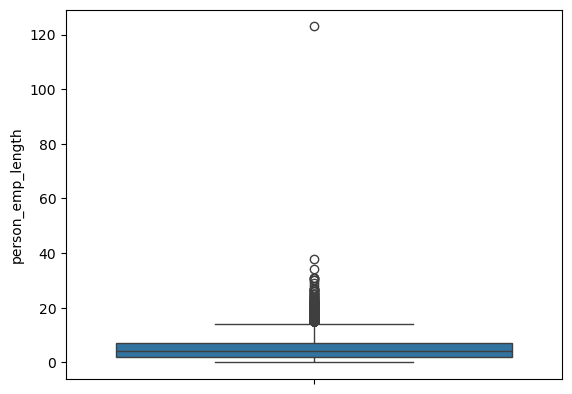

In [37]:
sns.boxplot(y=X_train["person_emp_length"])
plt.show()

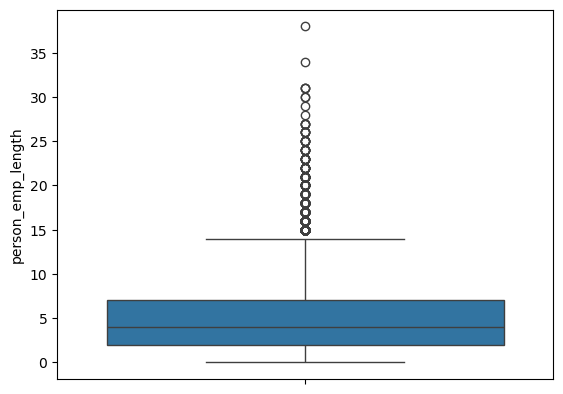

In [46]:
sns.boxplot(y=X_train["person_emp_length"])
plt.show()

In [34]:
X_train["loan_int_rate"].isnull().sum()

np.int64(2221)

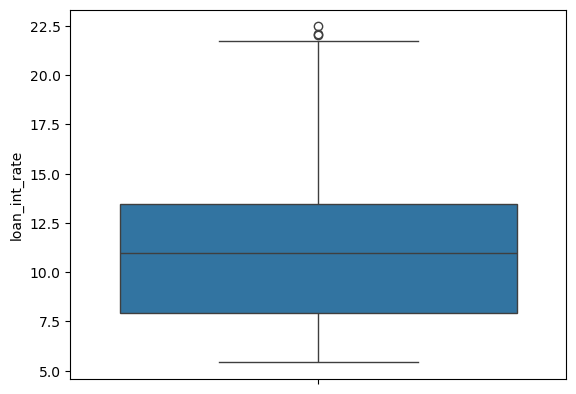

In [47]:
sns.boxplot(X_train["loan_int_rate"])
plt.show()

In [35]:
from sklearn.impute import SimpleImputer

In [57]:
transformer = ColumnTransformer(
    transformers=[
    ("median_imputer", SimpleImputer(strategy="median"), ["person_emp_length"]),
    ("mean_imputer", SimpleImputer(strategy="mean"), ["loan_int_rate"]),
    ("onehot", OneHotEncoder(drop="first"), nominal_features),
    ("binary", OrdinalEncoder(categories=[["N", "Y"]]), binary_features),
    ("ordinal", OrdinalEncoder(categories=[["A", "B", "C", "D", "E", "F", "G"]]), ordinal_features)],
    remainder="passthrough"
)

In [62]:
X_train_preprocessed = transformer.fit_transform(X_train)

In [63]:
X_train_preprocessed

array([[8.000e+00, 8.940e+00, 1.000e+00, ..., 1.000e+04, 1.600e-01,
        2.000e+00],
       [1.000e+00, 1.269e+01, 1.000e+00, ..., 4.000e+03, 1.000e-01,
        3.000e+00],
       [1.000e+00, 1.229e+01, 0.000e+00, ..., 7.500e+03, 6.000e-02,
        3.000e+00],
       ...,
       [0.000e+00, 6.540e+00, 0.000e+00, ..., 1.675e+03, 4.000e-02,
        3.000e+00],
       [8.000e+00, 1.491e+01, 0.000e+00, ..., 1.000e+04, 1.900e-01,
        4.000e+00],
       [2.100e+01, 1.521e+01, 0.000e+00, ..., 7.000e+03, 1.500e-01,
        1.700e+01]], shape=(22171, 17))

In [67]:
column_names = transformer.get_feature_names_out()

In [64]:
X_test_preprocessed = transformer.transform(X_test)

In [68]:
X_train_preprocessed = pd.DataFrame(data=X_train_preprocessed, columns=column_names)

In [69]:
X_train_preprocessed

,median_imputer__person_emp_length,mean_imputer__loan_int_rate,onehot__loan_intent_EDUCATION,onehot__loan_intent_HOMEIMPROVEMENT,onehot__loan_intent_MEDICAL,onehot__loan_intent_PERSONAL,onehot__loan_intent_VENTURE,onehot__person_home_ownership_OTHER,onehot__person_home_ownership_OWN,onehot__person_home_ownership_RENT,binary__cb_person_default_on_file,ordinal__loan_grade,remainder__person_age,remainder__person_income,remainder__loan_amnt,remainder__loan_percent_income,remainder__cb_person_cred_hist_length
0,8.0,8.94,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,25.0,62366.0,10000.0,0.16,2.0
1,1.0,12.69,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,22.0,40000.0,4000.0,0.10,3.0
2,1.0,12.29,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,25.0,131000.0,7500.0,0.06,3.0
3,5.0,14.35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,23.0,87000.0,15000.0,0.17,2.0
4,0.0,6.54,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,23.0,48000.0,6800.0,0.14,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22166,0.0,11.71,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,21.0,50000.0,12000.0,0.24,3.0
22167,5.0,11.71,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,29.0,26000.0,4500.0,0.17,5.0
22168,0.0,6.54,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,23.0,46300.0,1675.0,0.04,3.0
22169,8.0,14.91,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,24.0,53000.0,10000.0,0.19,4.0


In [70]:
X_test_preprocessed = pd.DataFrame(data=X_test_preprocessed, columns=column_names)

In [71]:
X_test_preprocessed

,median_imputer__person_emp_length,mean_imputer__loan_int_rate,onehot__loan_intent_EDUCATION,onehot__loan_intent_HOMEIMPROVEMENT,onehot__loan_intent_MEDICAL,onehot__loan_intent_PERSONAL,onehot__loan_intent_VENTURE,onehot__person_home_ownership_OTHER,onehot__person_home_ownership_OWN,onehot__person_home_ownership_RENT,binary__cb_person_default_on_file,ordinal__loan_grade,remainder__person_age,remainder__person_income,remainder__loan_amnt,remainder__loan_percent_income,remainder__cb_person_cred_hist_length
0,2.0,16.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,23.0,30000.0,12000.0,0.40,3.0
1,3.0,13.98,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,25.0,21996.0,8000.0,0.36,2.0
2,5.0,13.61,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,28.0,100000.0,11000.0,0.11,8.0
3,3.0,14.96,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,27.0,73580.0,19950.0,0.27,7.0
4,1.0,12.84,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,30.0,130000.0,8500.0,0.07,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9768,5.0,6.62,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,34.0,46000.0,10000.0,0.22,6.0
9769,5.0,16.49,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,3.0,23.0,60000.0,5000.0,0.08,2.0
9770,5.0,11.71,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,42.0,32000.0,10000.0,0.31,14.0
9771,1.0,9.63,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,23.0,59300.0,3000.0,0.05,3.0


In [72]:
X_train_preprocessed.info()

<class 'pandas.DataFrame'>
RangeIndex: 22171 entries, 0 to 22170
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   median_imputer__person_emp_length      22171 non-null  float64
 1   mean_imputer__loan_int_rate            22171 non-null  float64
 2   onehot__loan_intent_EDUCATION          22171 non-null  float64
 3   onehot__loan_intent_HOMEIMPROVEMENT    22171 non-null  float64
 4   onehot__loan_intent_MEDICAL            22171 non-null  float64
 5   onehot__loan_intent_PERSONAL           22171 non-null  float64
 6   onehot__loan_intent_VENTURE            22171 non-null  float64
 7   onehot__person_home_ownership_OTHER    22171 non-null  float64
 8   onehot__person_home_ownership_OWN      22171 non-null  float64
 9   onehot__person_home_ownership_RENT     22171 non-null  float64
 10  binary__cb_person_default_on_file      22171 non-null  float64
 11  ordinal__loan

In [73]:
X_test_preprocessed.info()

<class 'pandas.DataFrame'>
RangeIndex: 9773 entries, 0 to 9772
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   median_imputer__person_emp_length      9773 non-null   float64
 1   mean_imputer__loan_int_rate            9773 non-null   float64
 2   onehot__loan_intent_EDUCATION          9773 non-null   float64
 3   onehot__loan_intent_HOMEIMPROVEMENT    9773 non-null   float64
 4   onehot__loan_intent_MEDICAL            9773 non-null   float64
 5   onehot__loan_intent_PERSONAL           9773 non-null   float64
 6   onehot__loan_intent_VENTURE            9773 non-null   float64
 7   onehot__person_home_ownership_OTHER    9773 non-null   float64
 8   onehot__person_home_ownership_OWN      9773 non-null   float64
 9   onehot__person_home_ownership_RENT     9773 non-null   float64
 10  binary__cb_person_default_on_file      9773 non-null   float64
 11  ordinal__loan_g